# SHAP — task-indexed cheatsheet


SHAP explains a model's prediction by attributing it to features. **Per-row** SHAP values tell you *why this prediction*; **aggregating** them gives global feature importance, dependence patterns, and interaction insights.

Pick the right explainer for your model:

- `TreeExplainer` — exact and fast for tree ensembles (xgboost, lightgbm, sklearn trees).
- `LinearExplainer` — exact for linear models.
- `KernelExplainer` — model-agnostic, slow; falls back to this for arbitrary models.
- `DeepExplainer` — for neural nets (Keras / PyTorch).

The new `Explanation` API (`explainer(X)` rather than `explainer.shap_values(X)`) returns a richer object that powers the new plotting functions.


---
## Setup

Run this once.


### Setup — run me first


In [1]:
import numpy as np
import pandas as pd
import shap
import lightgbm as lgb
from sklearn.datasets import make_classification

rng = np.random.default_rng(0)
X_clf, y_clf = make_classification(n_samples=400, n_features=6, n_informative=4, random_state=0)
X_clf = pd.DataFrame(X_clf, columns=[f'f{i}' for i in range(6)])
X_clf_tr, X_clf_va = X_clf[:300], X_clf[300:]
y_clf_tr, y_clf_va = y_clf[:300], y_clf[300:]

# Fit a simple LightGBM model used by every example.
model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, verbosity=-1, random_state=0).fit(X_clf_tr, y_clf_tr)

# Sample for SHAP — full val on a small example, but in real life subsample to 1k–5k.
X_sample = X_clf_va.copy()

/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Computing SHAP values

Two APIs: the legacy `shap_values()` returns a numpy array; the newer `explainer(X)` returns an `Explanation` object that knows feature names and base values.


### How do I compute SHAP values for a tree model (legacy API)?

`shap.TreeExplainer(model).shap_values(X)`. Returns shape `(n, n_features)` for binary; for multiclass, a list of arrays.


In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print(f'shap_values shape: {shap_values.shape}')

shap_values shape: (100, 6)


/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


*Why TreeExplainer over KernelExplainer for trees*: TreeExplainer is exact and 100× faster. Always use it for xgboost/lightgbm/sklearn trees. *Common mistake*: passing a Pipeline (with a scaler) to TreeExplainer — pass the booster directly, or use `shap.Explainer(pipeline, X_train)` which auto-detects.


### How do I use the new Explanation API?

`explainer = shap.Explainer(model, X_train); exp = explainer(X)`. The `Explanation` object knows feature names and base values automatically.


In [3]:
explainer_new = shap.Explainer(model, X_clf_tr)
exp = explainer_new(X_sample)
print(f'exp.values shape:    {exp.values.shape}')
print(f'exp.base_values:     {exp.base_values[:3]}')
print(f'exp.feature_names:   {exp.feature_names}')

exp.values shape:    (100, 6)
exp.base_values:     [0.18450857 0.18450857 0.18450857]
exp.feature_names:   ['f0', 'f1', 'f2', 'f3', 'f4', 'f5']


*Why the new API*: works with `shap.plots.*` (bar, beeswarm, waterfall, scatter); base values and feature names are baked in, so plots automatically labelled. *When to use legacy*: when you need raw arrays for custom processing.


### How do I get global feature importance from SHAP values?

Mean absolute SHAP per feature: `np.abs(shap_values).mean(axis=0)`.


In [4]:
mean_abs = np.abs(shap_values).mean(axis=0)
imp = pd.Series(mean_abs, index=X_sample.columns).sort_values(ascending=False)
print(imp.round(4))

f2    2.2604
f3    2.0050
f5    2.0009
f4    1.7427
f1    1.4471
f0    0.8351
dtype: float64


*Why this rather than tree gain*: SHAP importance reflects how much each feature actually moves predictions on real data, not internal training-time gain. *Common mistake*: comparing SHAP importance and gain importance and being surprised they disagree — they measure different things.


---
## 2. The four plots you actually need

Beeswarm for global view; bar for ranked importance; waterfall for one prediction; dependence for one feature.


### How do I plot a beeswarm summary?

`shap.plots.beeswarm(exp)` — one row per feature, dots are samples, colour is feature value.


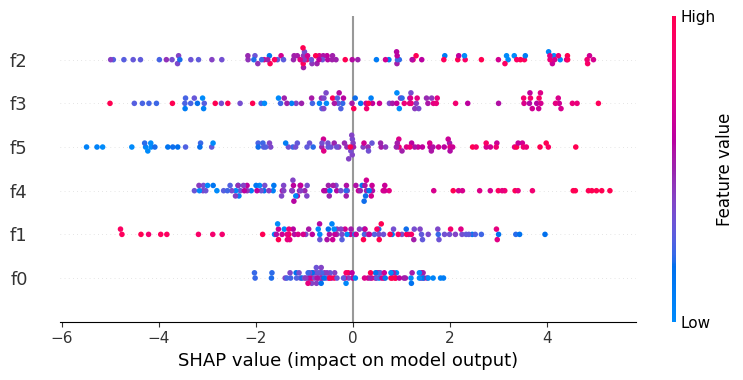

In [5]:
import matplotlib.pyplot as plt
shap.plots.beeswarm(exp, max_display=8, show=False)
plt.tight_layout(); plt.show()

*How to read*: each row is a feature; horizontal position is the SHAP value (impact on prediction); colour is feature value. Wide spread = the feature has variable impact; narrow = consistent impact. *Common mistake*: trying to read it like a histogram — beeswarm is conceptually different, focus on the *spread* and *colour gradient* per row.


### How do I plot ranked feature importance (bar plot)?

`shap.plots.bar(exp)` ranks features by mean |SHAP|.


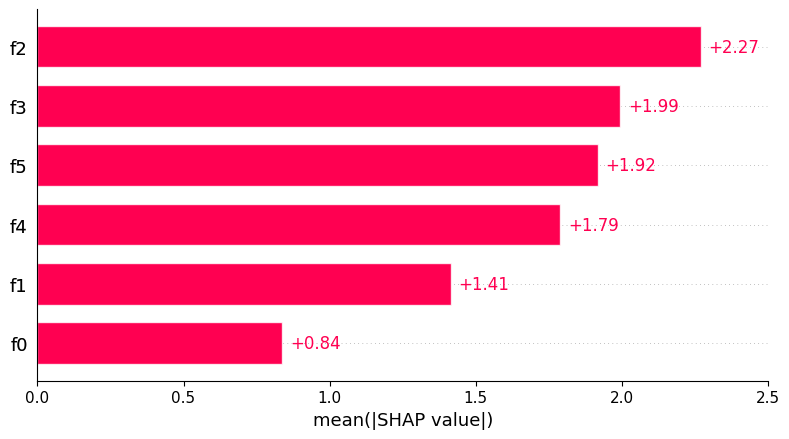

In [6]:
shap.plots.bar(exp, max_display=8, show=False)
plt.tight_layout(); plt.show()

*When to use over beeswarm*: when you only care about which features are important, not how their values affect predictions. Bar plot is one number per feature; beeswarm is a distribution per feature.


### How do I explain a single prediction (waterfall plot)?

`shap.plots.waterfall(exp[i])` shows how each feature pushed the prediction up or down from the base rate.


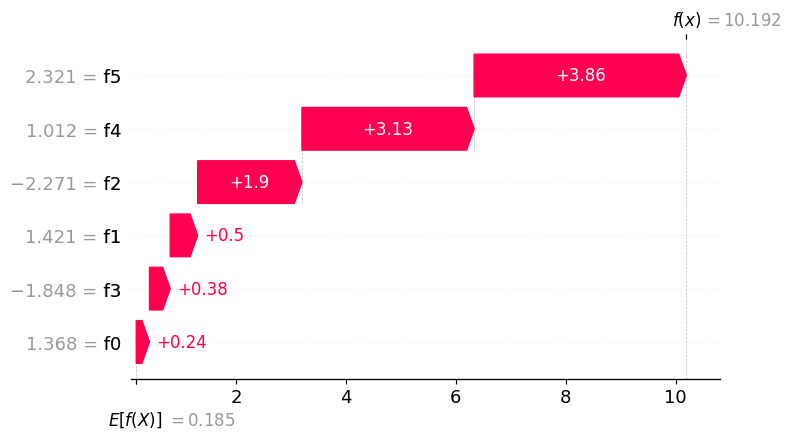

In [7]:
i = 0
shap.plots.waterfall(exp[i], max_display=8, show=False)
plt.tight_layout(); plt.show()

*How to read*: starts at base rate (average prediction); each bar adds or subtracts; ends at this row's prediction. Useful for debugging a specific surprising prediction. *Common mistake*: using waterfall on too many features (max_display=20) — the plot becomes unreadable; cap at 8-10.


### How do I see how a single feature interacts with the model?

`shap.plots.scatter(exp[:, 'feature_name'], color=exp)` shows feature value vs SHAP value, coloured by an auto-chosen interaction.


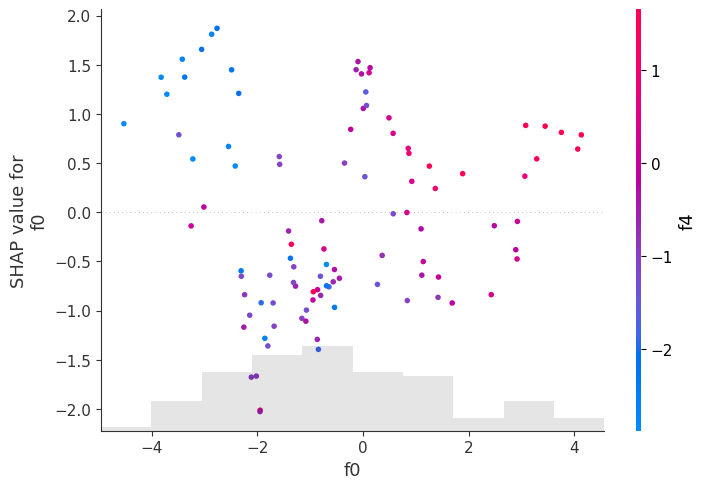

In [8]:
shap.plots.scatter(exp[:, 'f0'], color=exp, show=False)
plt.tight_layout(); plt.show()

*When to use*: investigating non-linearities or interactions in a specific feature. The auto-chosen colour reveals which other feature most modulates this one's effect. *Common mistake*: missing the interaction signal — colour gradient with a clear pattern means the feature's effect depends on another.


---
## 3. Explainers for other model types

TreeExplainer for trees; LinearExplainer for linear; KernelExplainer for everything else.


### How do I explain a linear model?

`shap.LinearExplainer(model, X_train)`. Exact and fast.


In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500).fit(X_clf_tr, y_clf_tr)
exp_lr = shap.LinearExplainer(lr, X_clf_tr)
shap_lr = exp_lr.shap_values(X_sample)
print(f'linear SHAP shape: {shap_lr.shape}')

linear SHAP shape: (100, 6)


*When to use*: any sklearn linear model (LogisticRegression, Ridge, Lasso, ElasticNet). *Common mistake*: using KernelExplainer on a linear model — slow for no reason.


### How do I explain an arbitrary model?

`shap.KernelExplainer(model.predict_proba, background)`. Slow — use a small background sample.


In [10]:
# Background sample of 50 — KernelExplainer is O(n_background × n_features × n_samples).
# Wrap predict_proba in a lambda and pass numpy arrays — avoids sklearn-attribute-setting
# quirks across library versions.
background = X_clf_tr.sample(n=50, random_state=0).values
exp_kernel = shap.KernelExplainer(lambda x: model.predict_proba(x), background)
shap_kernel = exp_kernel.shap_values(X_sample.iloc[:10].values, silent=True)
print(f'kernel SHAP shape: {np.array(shap_kernel).shape}')

/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/sklearn/utils/validation.

kernel SHAP shape: (10, 6, 2)


*Why background sample*: KernelExplainer needs a reference distribution to compute Shapley values against. *Common mistake*: passing the full training set as background — runtime explodes; 50–200 representative samples is enough.


---
## 4. Advanced: slicing the Explanation, interaction values

Two patterns that most SHAP tutorials skip but you'll want once you start poking at individual rows.


### How do I slice an Explanation object?

`exp[i]` for a single row; `exp[:, 'feat']` for a single feature; `exp[:, 'feat'].values` for the underlying array.


In [11]:
import shap
import lightgbm as lgb
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(n_samples=400, n_features=4, random_state=0)
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(4)])
m = lgb.LGBMClassifier(n_estimators=100, verbosity=-1).fit(X, y)
exp = shap.Explainer(m, X)(X)

print(f'shape:                   {exp.values.shape}')
print(f'one row:                 {exp[0].values.round(3)}')
print(f'one feature, all rows:   {exp[:, "f0"].values[:5].round(3)}')
print(f'top-10 by impact on f0:  {exp[:, "f0"].abs.argsort.values[-10:]}')

shape:                   (400, 4)
one row:                 [-0.611 -2.374 -0.44  -3.137]
one feature, all rows:   [-0.611 -2.332 -0.59   0.533  3.728]
top-10 by impact on f0:  [349 368 233 308   4 270 291  91 314  49]


*When to use*: programmatic per-row / per-feature analysis without going through pyplot. *Common mistake*: trying `exp.values[:, 'f0']` — that's a numpy array, doesn't accept string indexing; use `exp[:, 'f0']` (the Explanation knows feature names).


### How do I see feature INTERACTIONS?

`explainer.shap_interaction_values(X)` returns a 3-D array `(n, n_features, n_features)`.


In [12]:
import shap
import lightgbm as lgb
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(n_samples=200, n_features=4, random_state=0)
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(4)])
m = lgb.LGBMClassifier(n_estimators=50, verbosity=-1).fit(X, y)

explainer = shap.TreeExplainer(m)
sv = explainer.shap_interaction_values(X.iloc[:50])
print(f'interaction shape: {sv.shape}')   # (50, 4, 4)

# Diagonal = main effects; off-diagonal = pairwise interactions.
import numpy as np
mean_abs = np.abs(sv).mean(axis=0)
pair = pd.DataFrame(mean_abs, index=X.columns, columns=X.columns)
print(pair.round(3))


interaction shape: (50, 4, 4)
       f0     f1     f2     f3
f0  2.634  0.090  0.062  0.177
f1  0.090  0.591  0.027  0.267
f2  0.062  0.027  0.177  0.063
f3  0.177  0.267  0.063  1.665


*When to use*: identifying which feature pairs matter together — beyond what each does on its own. *Common mistake*: running on the full dataset and waiting forever — interaction-value computation scales as O(n × n_features²); subsample to ~500-1000 rows.
